# 反復量子振幅推定（Iterative Quantum Amplitude Estimation (IQAE)）

ここでは、反復量子振幅推定アルゴリズムを使って振幅推定の例を見てみます。例として取り上げるのは、1) ハイゼンベルク模型での時間発展状態、2) 量子センシングを想定した微小信号による状態変化です。

まず必要なパッケージをロードします。

In [1]:
import sys
import shutil
import tarfile
from google.colab import drive
drive.mount('/content/gdrive')
shutil.copy('/content/gdrive/MyDrive/qcintro.tar.gz', '.')
with tarfile.open('qcintro.tar.gz', 'r:gz') as tar:
    tar.extractall(path='/root/.local')

sys.path.append('/root/.local/lib/python3.12/site-packages')

Mounted at /content/gdrive


/tmp/ipykernel_8545/1129522405.py:8: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path='/root/.local')


In [2]:
%pip install qiskit-algorithms

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.8/327.8 kB 5.6 MB/s eta 0:00:00


In [3]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit_aer.primitives import SamplerV2 as AerSampler

from qiskit_algorithms import IterativeAmplitudeEstimation, EstimationProblem
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import PauliEvolutionGate

## ハミルトニアン時間発展での振幅推定

横磁場イジング模型での時間発展状態の量子振幅を、反復量子振幅推定アルゴリズムを使って推定してみます。

In [22]:
# ハミルトニアンの定義 (1D ハイゼンベルク模型)
# -------------------------------------
# スピン数
n_qubits = 6
# 結合の強さ
J = 1.5
# 境界条件
PBC = True

# ハミルトニアン生成
def heisenberg_hamiltonian(n, J=1.0, pbc=False):
    paulis = []
    coeffs = []

    if pbc:
        pairs = [(i, (i + 1) % n) for i in range(n)]
    else:
        pairs = [(i, i + 1) for i in range(n - 1)]

    for i, j in pairs:
      for p in ['X', 'Y', 'Z']:
        s = ['I']*n
        s[i] = p
        s[j] = p
        paulis.append("".join(s))
        coeffs.append(J)

    H = SparsePauliOp(paulis, coeffs)
    return H

hamiltonian = heisenberg_hamiltonian(n_qubits, J, PBC)


# 時間発展演算子と状態準備回路
# -----------------------
evolution_time = 3.0
# 1次のLie-Trotter-Suzuki分解
evolution_gate = PauliEvolutionGate(hamiltonian, time=evolution_time)

# 初期状態|000011>から時間発展させる
qc = QuantumCircuit(n_qubits)
qc.x(0)
qc.x(1)
qc.append(evolution_gate, range(n_qubits))


# 推定問題の定義
#   ターゲット:|110000>状態への遷移確率
# ---------------------------------
# objective_qubitsにリストを渡すと、指定した全ビットが '1' である状態がターゲット

# 測定基底を変える:|110000>を|111111>に変換
qc_measure = qc.copy()
qc_measure.x(range(4))

problem = EstimationProblem(
    state_preparation=qc_measure,
    objective_qubits=[0,1,2,3,4,5]
)


# 反復量子振幅推定 (IQAE) の実行
# ---------------------------
sampler = StatevectorSampler()
iae = IterativeAmplitudeEstimation(
    epsilon_target = 0.001,
    alpha = 0.05,
    sampler = sampler
)
result = iae.estimate(problem)


# 結果の抽出と厳密値との比較
# ----------------------
# StatevectorSamplerを用いて厳密な状態ベクトルから真の遷移確率を計算
from qiskit.quantum_info import Statevector
exact_sv = Statevector(qc)
exact_prob = np.abs(exact_sv.data[48])**2 # インデックス48が|110000>

print("--- Estimation Results ---")
print(f"Target State Probability (Exact) : {exact_prob:.5f}")
print(f"Estimated Probability (IQAE)     : {result.estimation:.5f}")
print(f"Total Oracle Queries             : {result.num_oracle_queries}")

/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_dsolve/linsolve.py:606: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/usr/local/lib/python3.12/dist-packages/scipy/sparse/linalg/_matfuncs.py:707: SparseEfficiencyWa

--- Estimation Results ---
Target State Probability (Exact) : 0.15203
Estimated Probability (IQAE)     : 0.15209
Total Oracle Queries             : 80896


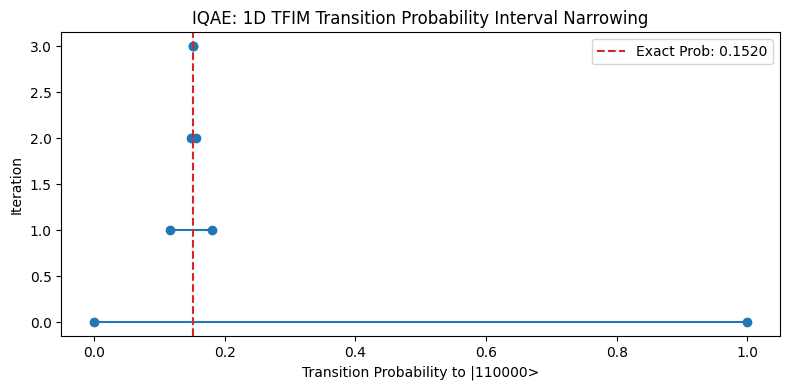

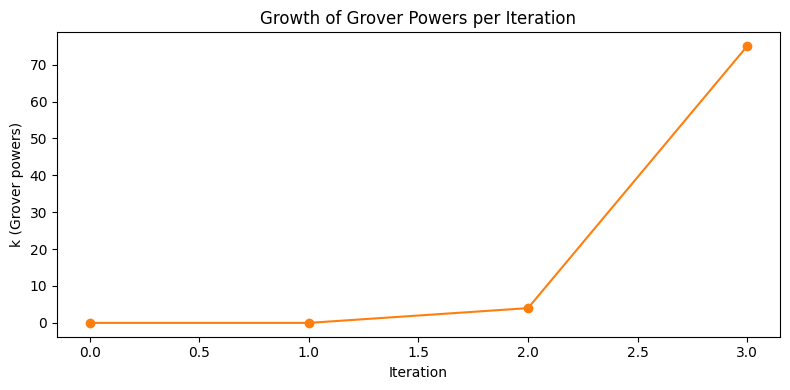

In [23]:
# 可視化 (振幅/確率スケールでのプロット)
# ---------------------------------
k_values = result.powers
theta_intervals = result.theta_intervals

amplitude_intervals = []
for low, high in theta_intervals:
    a_low = np.sin(2 * np.pi * low)**2
    a_high = np.sin(2 * np.pi * high)**2
    amplitude_intervals.append((a_low, a_high))

fig, ax = plt.subplots(figsize=(8, 4))
for i, (low, high) in enumerate(amplitude_intervals):
    ax.plot([low, high], [i, i], marker='o', color='tab:blue')

ax.axvline(exact_prob, color='tab:red', linestyle='--', label=f'Exact Prob: {exact_prob:.4f}')
ax.set_xlabel("Transition Probability to |110000>")
ax.set_ylabel("Iteration")
ax.set_title("IQAE: 1D TFIM Transition Probability Interval Narrowing")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(len(k_values)), k_values, marker='o', color='tab:orange')
ax.set_xlabel("Iteration")
ax.set_ylabel("k (Grover powers)")
ax.set_title("Growth of Grover Powers per Iteration")
plt.tight_layout()
plt.show()

## 微小信号の振幅推定

外部場が量子ビットに微小なラビ振動を起こすケース（例えば、量子センシング）を想定して、その確率振幅を反復量子振幅推定アルゴリズムを使って推定してみます。

In [30]:
# 微小パラメータの設定 (量子センシングモデル)
# ------------------------------------
# 外部場との極めて弱い相互作用と時間の積を、微小な回転角θとしてエンコードする
# 例えば、結合定数が極めて小さい未知の粒子の影響
theta_physical = 0.01  # 小さな回転角
exact_amplitude = np.sin(theta_physical / 2)**2

# 1量子ビットのセンシング回路
qc = QuantumCircuit(1)
# 微小信号をY軸回転として状態に変換
qc.ry(theta_physical, 0)


# 推定問題の定義
# ------------
# 目標状態は|1>
# この振幅a = sin^2(θ/2)を高精度で推定する
problem = EstimationProblem(
    state_preparation = qc,
    objective_qubits = [0]
)


# 高精度推定を目指したIQAEの実行
# --------------------------
# 目標精度を1e-5に設定（古典サンプリングとの比較を行う）
target_precision = 1e-5

sampler = StatevectorSampler()
iae = IterativeAmplitudeEstimation(
    epsilon_target = target_precision,
    alpha = 0.05,  # 95% 信頼区間
    sampler = sampler
)

print(f"Target Amplitude to estimate: {exact_amplitude:.4e}")
print(f"Target Precision (epsilon):   {target_precision:.4e}\n")
print("Running IQAE... (This could take some time due to deep Grover iterations)\n")

result = iae.estimate(problem)


# 結果の抽出とリソース評価
# --------------------
# 古典的なモンテカルロ法(ショットサンプリング)で同精度を出すのに必要な概算ショット数
# (Chernoff bound: N ≈ 1 / (epsilon^2))
classical_shots_needed = int(1 / (target_precision**2))

print("--- Estimation Results ---")
print(f"Exact Amplitude   : {exact_amplitude:.8e}")
print(f"Estimated (IQAE)  : {result.estimation:.8e}")
print(f"Estimation Error  : {abs(exact_amplitude - result.estimation):.8e}\n")

print("--- Resource Comparison ---")
print(f"Quantum Oracle Queries (IQAE)       : {result.num_oracle_queries:,}")
print(f"Equivalent Classical Shots          : ~{classical_shots_needed:,}")
if result.num_oracle_queries > 0:
    ratio = classical_shots_needed / result.num_oracle_queries
    print(f"Classical Shot/Quantum Query Ratio  : ~{ratio:,.1f}")

Target Amplitude to estimate: 2.5000e-05
Target Precision (epsilon):   1.0000e-05

Running IQAE... (This could take some time due to deep Grover iterations)

--- Estimation Results ---
Exact Amplitude   : 2.49997917e-05
Estimated (IQAE)  : 2.50002876e-05
Estimation Error  : 4.95933949e-10

--- Resource Comparison ---
Quantum Oracle Queries (IQAE)       : 27,105,280
Equivalent Classical Shots          : ~9,999,999,999
Classical Shot/Quantum Query Ratio  : ~368.9


<>:19: SyntaxWarning: invalid escape sequence '\e'
<>:19: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_8545/1393423638.py:19: SyntaxWarning: invalid escape sequence '\e'
  ax1.axhline(target_precision, color='tab:red', linestyle='--', label="Target Precision ($\epsilon$)")


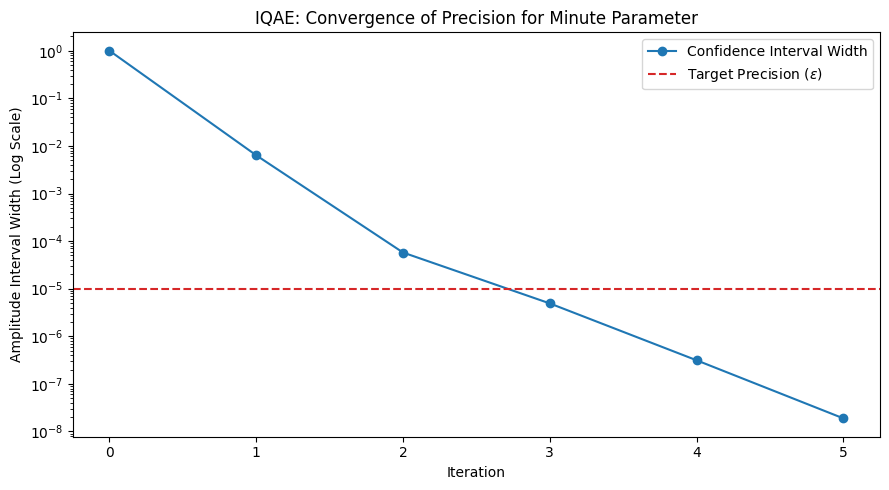

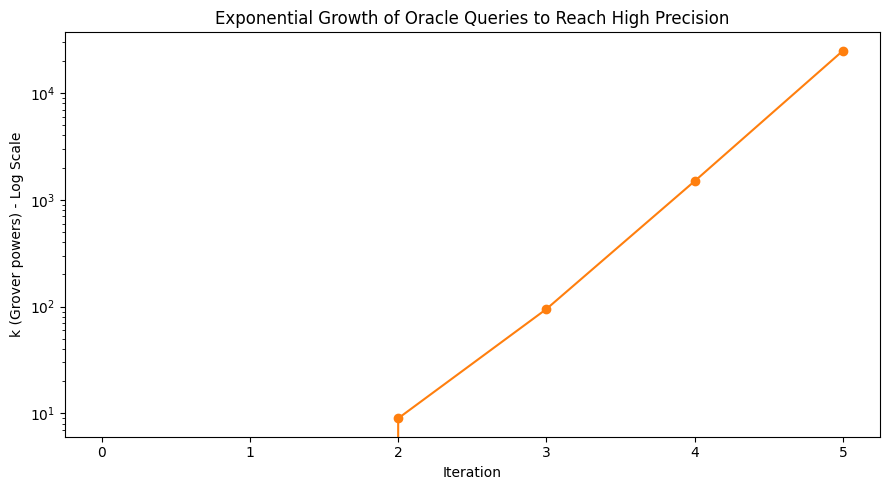

In [31]:
# 可視化 (微小スケールでの区間収束)
# ----------------------------
k_values = result.powers
theta_intervals = result.theta_intervals

# "a = sin^2(2 * pi * theta)"に基づいて振幅に変換
amplitude_intervals = []
for low, high in theta_intervals:
    a_low = np.sin(2 * np.pi * low)**2
    a_high = np.sin(2 * np.pi * high)**2
    amplitude_intervals.append((a_low, a_high))


fig, ax1 = plt.subplots(figsize=(9, 5))

# 対数スケールで見やすいように、真の値からの絶対誤差（信頼区間の幅）をプロット
interval_widths = [high - low for low, high in amplitude_intervals]
ax1.plot(iterations, interval_widths, marker='o', color='tab:blue', label="Confidence Interval Width")
ax1.axhline(target_precision, color='tab:red', linestyle='--', label="Target Precision ($\epsilon$)")

ax1.set_yscale('log')
ax1.set_xlabel("Iteration")
ax1.set_ylabel("Amplitude Interval Width (Log Scale)")
ax1.set_title("IQAE: Convergence of Precision for Minute Parameter")
ax1.legend()
plt.tight_layout()
plt.show()

# Grover演算回数の成長を対数スケールでプロット
fig, ax2 = plt.subplots(figsize=(9, 5))
ax2.plot(iterations, k_values, marker='o', color='tab:orange')
ax2.set_yscale('log')
ax2.set_xlabel("Iteration")
ax2.set_ylabel("k (Grover powers) - Log Scale")
ax2.set_title("Exponential Growth of Oracle Queries to Reach High Precision")
plt.tight_layout()
plt.show()